# Resume–Job Skill Gap Analysis

Use this notebook for exploratory analysis, statistical tests, visualizations, and interpretation. Keep reusable logic in `src/`.

In [1]:
import sys
sys.path.append('../backend')
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from extract_skills import get_skill_pattern, extract_skills

In [2]:
sns.set()

## 1. Data Validation

Record raw counts, missing values, duplicate counts, and cleaning decisions before modelling.

In [3]:
# Define raw file paths
raw_jobs_file = '../data/raw/jobs.csv'
raw_courses_file = '../data/raw/courses.csv'
raw_resumes_file = '../data/raw/resumes.csv'

In [4]:
# Define cleaned file paths
cleaned_jobs_file = '../data/processed/jobs_clean.csv'
cleaned_courses_file = '../data/processed/courses_clean.csv'
cleaned_resumes_file = '../data/processed/resumes_clean.csv'

In [5]:
# Read raw CSV files
raw_jobs = pd.read_csv(raw_jobs_file)
raw_courses = pd.read_csv(raw_courses_file)
raw_resumes = pd.read_csv(raw_resumes_file)

In [6]:
# Read cleaned CSV files
cleaned_jobs = pd.read_csv(cleaned_jobs_file)
cleaned_courses = pd.read_csv(cleaned_courses_file)
cleaned_resumes = pd.read_csv(cleaned_resumes_file)

In [7]:
# Print raw dataset sizes
print('Raw Jobs:', raw_jobs.shape)
print('Raw Courses:', raw_courses.shape)
print('Raw Resumes:', raw_resumes.shape)

Raw Jobs: (300, 9)
Raw Courses: (166, 3)
Raw Resumes: (2484, 4)


In [8]:
# Print cleaned dataset sizes
print('Cleaned Jobs:', cleaned_jobs.shape)
print('Cleaned Courses:', cleaned_courses.shape)
print('Cleaned Resumes:', cleaned_resumes.shape)

Cleaned Jobs: (93, 10)
Cleaned Courses: (93, 5)
Cleaned Resumes: (100, 6)


In [9]:
skill_patterns = get_skill_pattern()

## 2. Exploratory data analysis

Answer the research questions.

### 2.1. JOB EDA

In [10]:
# Count jobs in each category
jobs_per_category = cleaned_jobs['category'].value_counts().sort_index()
print(jobs_per_category)

category
Computer and IT            20
Data and Analytics         45
Science and Engineering     9
Software Engineering       19
Name: count, dtype: int64


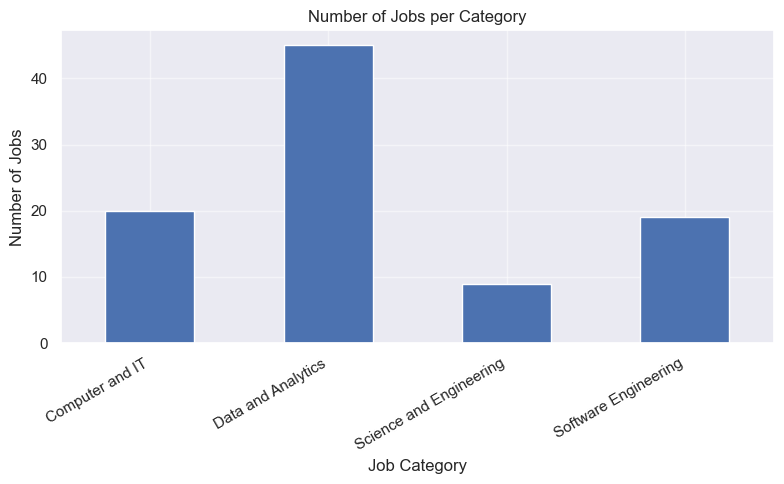

In [11]:
# Plot jobs per category
plt.figure(figsize=(8, 5))
jobs_per_category.plot(kind='bar')
plt.title('Number of Jobs per Category')
plt.xlabel('Job Category')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/jobs_per_category.png')
plt.show()

In [12]:
# Count unique companies in each job category
companies_per_category = cleaned_jobs.groupby('category')['company'].nunique().sort_values(ascending=False)
print(companies_per_category)

category
Data and Analytics         26
Computer and IT            19
Software Engineering       11
Science and Engineering     7
Name: company, dtype: int64


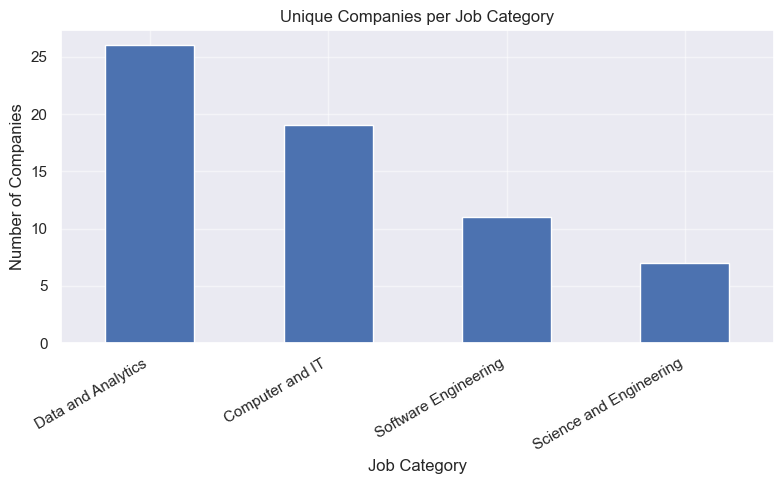

In [13]:
# Plot unique companies per category
plt.figure(figsize=(8, 5))
companies_per_category.plot(kind='bar')
plt.title('Unique Companies per Job Category')
plt.xlabel('Job Category')
plt.ylabel('Number of Companies')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/companies_per_category.png')
plt.show()

In [14]:
# Count jobs at each experience level
job_levels = cleaned_jobs['job_level'].value_counts()
print(job_levels)

job_level
Senior Level    65
Mid Level       26
Entry Level      1
Internship       1
Name: count, dtype: int64


In [15]:
# Compare job levels between categories
job_level_category = pd.crosstab(cleaned_jobs['category'], cleaned_jobs['job_level'])
print(job_level_category)

job_level                Entry Level  Internship  Mid Level  Senior Level
category                                                                 
Computer and IT                    0           0          6            14
Data and Analytics                 1           0         13            31
Science and Engineering            0           0          4             5
Software Engineering               0           1          3            15


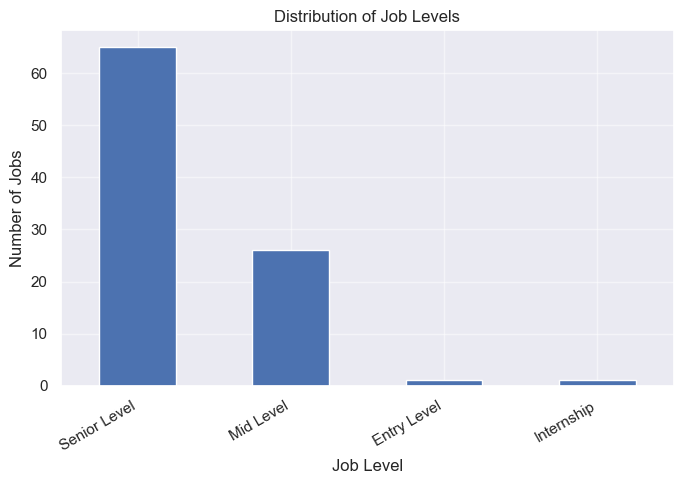

In [16]:
# Plot job levels
plt.figure(figsize=(7, 5))
job_levels.plot(kind='bar')
plt.title('Distribution of Job Levels')
plt.xlabel('Job Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/job_levels_distribution.png')
plt.show()

In [17]:
# Create word and two-word term counts
job_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=3)
job_term_matrix = job_vectorizer.fit_transform(cleaned_jobs['cleaned_description'])

# Get term names and total frequencies
job_terms = job_vectorizer.get_feature_names_out()
job_term_counts = pd.Series(np.asarray(job_term_matrix.sum(axis=0)).ravel(), index=job_terms).sort_values(ascending=False)

# Show the most frequent terms
print(job_term_counts.head(30))

data              654
experience        606
business          352
benefits          291
team              287
work              283
technical         262
including         257
engineering       227
qualifications    224
solutions         219
ai                216
skills            203
information       200
software          191
walmart           188
related           183
support           182
management        179
years             176
development       173
performance       172
systems           170
learning          169
cloud             168
tools             167
design            166
teams             165
job               164
requirements      163
dtype: int64


In [18]:
# Extract technical skills from each job
job_skills = []

for job_description in cleaned_jobs['cleaned_description']:
    current_skills = extract_skills(job_description, skill_patterns)
    job_skills.append(current_skills)

# Store technical skills for each job
cleaned_jobs['tech_skills'] = job_skills

# Put each technical skill into its own row
job_skills_exploded = cleaned_jobs['tech_skills'].explode()

# Count how many jobs mention each skill
job_skill_counts = job_skills_exploded.value_counts()

# Show most common technical skills
print(job_skill_counts.head(20))

tech_skills
python              44
sql                 32
agile               31
azure               29
machine learning    27
aws                 23
gcp                 20
cybersecurity       19
java                19
ci/cd               15
data analysis       15
data science        14
spark               12
kubernetes          10
pytorch             10
jira                10
jenkins              9
github               9
javascript           9
docker               8
Name: count, dtype: int64


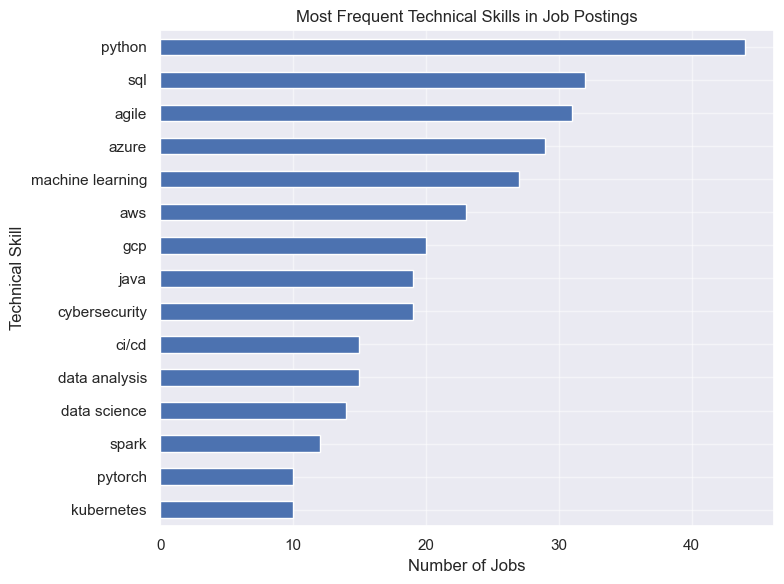

In [19]:
# Plot the 15 most common job skills
top_job_skills = job_skill_counts.head(15)

plt.figure(figsize=(8, 6))
top_job_skills.sort_values().plot(kind='barh')
plt.title('Most Frequent Technical Skills in Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.savefig('../figures/most_freq_tech_skills_job.png')
plt.show()

In [20]:
# Create technical skill presence matrix for jobs
job_skill_matrix = pd.crosstab(job_skills_exploded.index, job_skills_exploded)

# Convert counts to binary presence
job_skill_matrix = (job_skill_matrix > 0).astype(int)

# Add back jobs with no detected technical skills
job_skill_matrix = job_skill_matrix.reindex(cleaned_jobs.index, fill_value=0)

In [21]:
# Add job category to the skill table
job_skill_category = job_skill_matrix.copy()
job_skill_category['category'] = cleaned_jobs['category'].values

# Select the most common skills
top_skill_names = job_skill_counts.head(12).index.tolist()

# Calculate percentage of jobs mentioning each skill
category_skill_rate = job_skill_category.groupby('category')[top_skill_names].mean() * 100

print(category_skill_rate.round(1))

tech_skills              python   sql  agile  azure  machine learning   aws  \
category                                                                      
Computer and IT            15.0  20.0   25.0   40.0              15.0  40.0   
Data and Analytics         62.2  51.1   35.6   24.4              40.0  15.6   
Science and Engineering    33.3  11.1    0.0   33.3              33.3  33.3   
Software Engineering       52.6  21.1   52.6   36.8              15.8  26.3   

tech_skills               gcp  cybersecurity  java  ci/cd  data analysis  \
category                                                                   
Computer and IT          25.0           40.0   5.0   15.0            5.0   
Data and Analytics       17.8            8.9  15.6    6.7           24.4   
Science and Engineering  22.2           22.2  11.1   11.1           22.2   
Software Engineering     26.3           26.3  52.6   42.1            5.3   

tech_skills              data science  
category                    

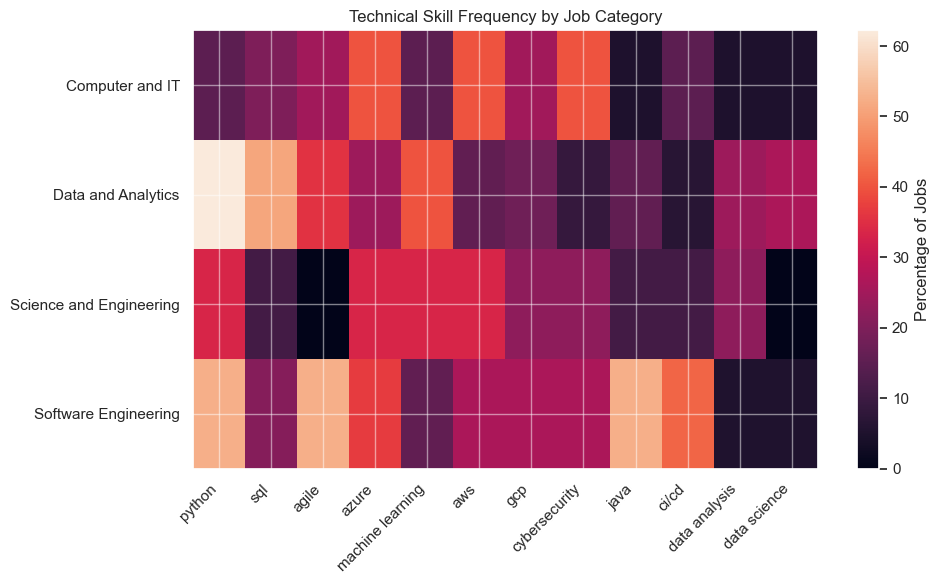

In [22]:
# Plot technical skill differences among categories
plt.figure(figsize=(10, 6))
plt.imshow(category_skill_rate, aspect='auto')
plt.xticks(range(len(top_skill_names)), top_skill_names, rotation=45, ha='right')
plt.yticks(range(len(category_skill_rate.index)), category_skill_rate.index)
plt.colorbar(label='Percentage of Jobs')
plt.title('Technical Skill Frequency by Job Category')
plt.tight_layout()
plt.savefig('../figures/job_tech_skills_freq_heatmap.png')
plt.show()

### 2.2. RESUME EDA

In [23]:
# Show technical skill count statistics
print(cleaned_resumes['num_tech_skills'].describe())

count    100.000000
mean       6.510000
std        4.611131
min        1.000000
25%        3.000000
50%        6.000000
75%        9.000000
max       24.000000
Name: num_tech_skills, dtype: float64


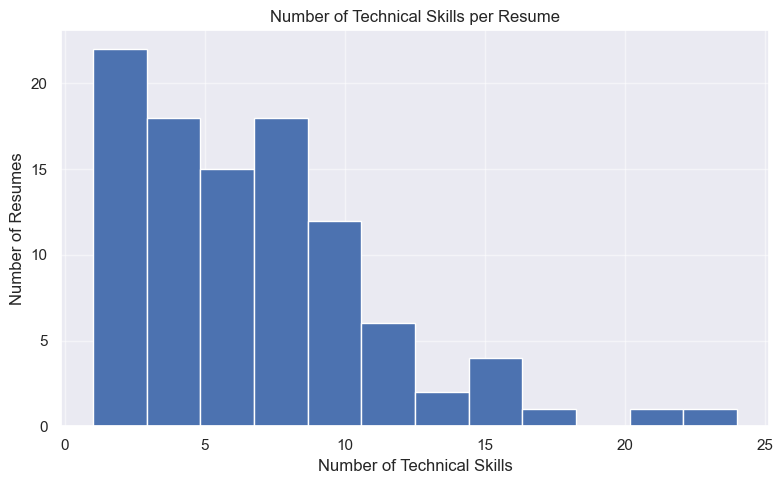

In [24]:
# Plot technical skill counts
plt.figure(figsize=(8, 5))
plt.hist(cleaned_resumes['num_tech_skills'], bins=12)
plt.title('Number of Technical Skills per Resume')
plt.xlabel('Number of Technical Skills')
plt.ylabel('Number of Resumes')
plt.tight_layout()
plt.savefig('../figures/num_tech_skills_per_resume.png')
plt.show()

In [25]:
# Convert stored skill strings back to sets
cleaned_resumes['tech_skills_list'] = cleaned_resumes['tech_skills'].apply(ast.literal_eval)

# Put every skill into its own row
resume_skills = cleaned_resumes['tech_skills_list'].explode()

# Count the most common resume skills
resume_skill_counts = resume_skills.value_counts()

print(resume_skill_counts.head(20))

tech_skills_list
windows                 68
active directory        44
sql                     40
cisco                   39
linux                   30
lan                     27
sharepoint              25
oracle                  24
wan                     23
vmware                  22
network security        19
html                    19
information security    18
unix                    18
tcp/ip                  17
firewall                16
sql server              15
data analysis           13
java                    11
css                     10
Name: count, dtype: int64


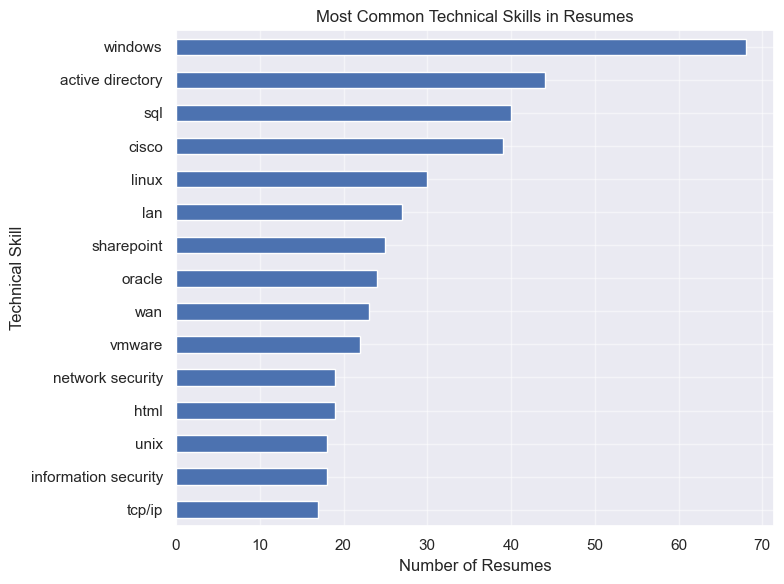

In [26]:
# Plot the 15 most common resume skills
top_resume_skills = resume_skill_counts.head(15)

plt.figure(figsize=(8, 6))
top_resume_skills.sort_values().plot(kind='barh')
plt.title('Most Common Technical Skills in Resumes')
plt.xlabel('Number of Resumes')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.savefig('../figures/most_common_tech_skills_resume.png')
plt.show()

### 2.3. COURSE EDA

In [27]:
# Remove prerequisite text for concept-frequency analysis
cleaned_courses['eda_description'] = (cleaned_courses['cleaned_description'].str.replace(r'(?i)\bprerequisite:.*$', ' ',regex=True))

# Define course-specific uninformative words
course_stop_words = [
    'course',
    'courses',
    'student',
    'students',
    'credit',
    'credits',
    'cmpt',
    'prerequisite'
]

# Create term counts
course_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2)
course_term_matrix = course_vectorizer.fit_transform(cleaned_courses['eda_description'])

# Get term frequencies
course_terms = course_vectorizer.get_feature_names_out()

course_term_counts = pd.Series(np.asarray(course_term_matrix.sum(axis=0)).ravel(), index=course_terms).sort_values(ascending=False)

# Remove common administrative terms
course_term_counts = course_term_counts[~course_term_counts.index.isin(course_stop_words)]

print(course_term_counts.head(30))

data                 64
systems              63
topics               53
computer             35
programming          35
computing            34
design               31
include              31
algorithms           30
topics include       27
software             26
techniques           25
learning             22
science              21
concepts             19
analysis             19
advanced             19
introduction         17
computing science    16
models               16
including            16
network              16
security             16
information          15
fundamental          15
covers               15
research             14
web                  14
applications         14
experience           13
dtype: int64


In [28]:
# Extract technical skills from each course
course_skills = []

for course_description in cleaned_courses['cleaned_description']:
    current_skills = extract_skills(course_description, skill_patterns)
    course_skills.append(current_skills)

# Store technical skills for each course
cleaned_courses['tech_skills'] = course_skills

# Put each technical skill into its own row
course_skills_exploded = cleaned_courses['tech_skills'].explode()

# Count how many courses mention each skill
course_skill_counts = course_skills_exploded.value_counts()

# Show most common technical skills
print(course_skill_counts.head(20))

tech_skills
machine learning    8
data analysis       3
cybersecurity       3
c++                 2
network security    2
deep learning       2
tcp/ip              2
python              1
unix                1
java                1
html                1
javascript          1
typescript          1
rest                1
css                 1
spring              1
switching           1
data science        1
Name: count, dtype: int64


In [29]:
# Create job and course skill comparison
market_skill_summary = pd.DataFrame(
    {
        'job_count': job_skill_counts,
        'course_count': course_skill_counts
    }
)

# Keep skills that appear in the job market
market_skill_summary = market_skill_summary[market_skill_summary['job_count'] > 0]

# Sort by job-market frequency
market_skill_summary = market_skill_summary.sort_values(by='job_count', ascending=False)

print(market_skill_summary.head(30))

                  job_count  course_count
tech_skills                              
python                   44           1.0
sql                      32           NaN
agile                    31           NaN
azure                    29           NaN
machine learning         27           8.0
aws                      23           NaN
gcp                      20           NaN
java                     19           1.0
cybersecurity            19           3.0
data analysis            15           3.0
ci/cd                    15           NaN
data science             14           1.0
spark                    12           NaN
kubernetes               10           NaN
pytorch                  10           NaN
jira                     10           NaN
javascript                9           1.0
github                    9           NaN
jenkins                   9           NaN
docker                    8           NaN
tensorflow                8           NaN
spring                    7       

In [30]:
# Find market skills never mentioned in course descriptions
skills_not_in_courses = market_skill_summary[market_skill_summary['course_count'] == 0]

print('Market skills not mentioned in courses:')
print(skills_not_in_courses)

Market skills not mentioned in courses:
Empty DataFrame
Columns: [job_count, course_count]
Index: []


In [31]:
# Find market skills appearing in only one course
rare_course_skills = market_skill_summary[market_skill_summary['course_count'] == 1]

print('Market skills mentioned in only one course:')
print(rare_course_skills)

Market skills mentioned in only one course:
              job_count  course_count
tech_skills                          
python               44           1.0
java                 19           1.0
data science         14           1.0
javascript            9           1.0
spring                7           1.0
rest                  5           1.0
typescript            4           1.0
unix                  3           1.0
css                   2           1.0
switching             2           1.0
html                  1           1.0


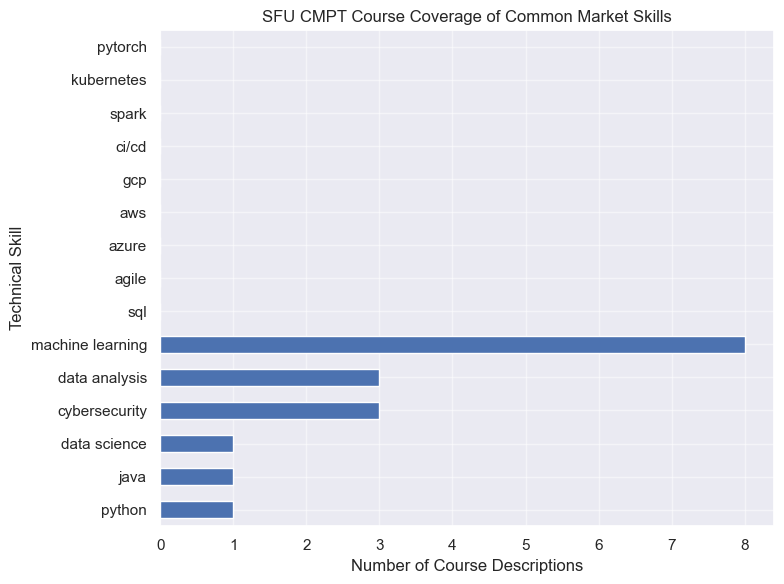

In [32]:
# Select the most frequent market skills
top_market_skills = market_skill_summary.head(15).copy()

# Plot course coverage for the same market skills
plt.figure(figsize=(8, 6))
top_market_skills['course_count'].sort_values().plot(kind='barh')
plt.title('SFU CMPT Course Coverage of Common Market Skills')
plt.xlabel('Number of Course Descriptions')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.savefig('../figures/tech_skills_course_coverage.png')
plt.show()

## 3. Model evaluation

Compare the keyword baseline against TF-IDF on held-out labels.

In [33]:
# Define evaluation results file path
eva_results_file = '../outputs/evaluation/evaluation_results.csv'

In [34]:
# Read held-out model evaluation results
evaluation_results = pd.read_csv(eva_results_file)

# Check evaluation sample size
print('Evaluation pairs:', len(evaluation_results))

Evaluation pairs: 20


### 3.1. Baseline performance

In [35]:
# Show baseline evaluation metrics
baseline_metrics = evaluation_results[
    [
        'baseline_precision',
        'baseline_recall',
        'baseline_jaccard'
    ]
].mean()

print(baseline_metrics.round(4))

baseline_precision    0.3637
baseline_recall       0.3375
baseline_jaccard      0.2086
dtype: float64


### 3.2. TF-IDF performance

In [36]:
# Show TF-IDF evaluation metrics
tfidf_metrics = evaluation_results[
    [
        'tfidf_precision_3',
        'tfidf_recall_3',
        'tfidf_precision_5',
        'tfidf_recall_5',
        'tfidf_jaccard_5'
    ]
].mean()

print(tfidf_metrics.round(4))

tfidf_precision_3    0.3583
tfidf_recall_3       0.1875
tfidf_precision_5    0.3858
tfidf_recall_5       0.2775
tfidf_jaccard_5      0.2142
dtype: float64


### 3.3. Baseline vs TF-IDF

In [37]:
# Create baseline and TF-IDF comparison table
model_comparison = pd.DataFrame(
    {
        'baseline': [
            evaluation_results['baseline_precision'].mean(),
            evaluation_results['baseline_recall'].mean(),
            evaluation_results['baseline_jaccard'].mean()
        ],
        'tfidf_top_5': [
            evaluation_results['tfidf_precision_5'].mean(),
            evaluation_results['tfidf_recall_5'].mean(),
            evaluation_results['tfidf_jaccard_5'].mean()
        ]
    },
    index = ['precision', 'recall', 'jaccard']
)

print(model_comparison.round(4))

           baseline  tfidf_top_5
precision    0.3637       0.3858
recall       0.3375       0.2775
jaccard      0.2086       0.2142


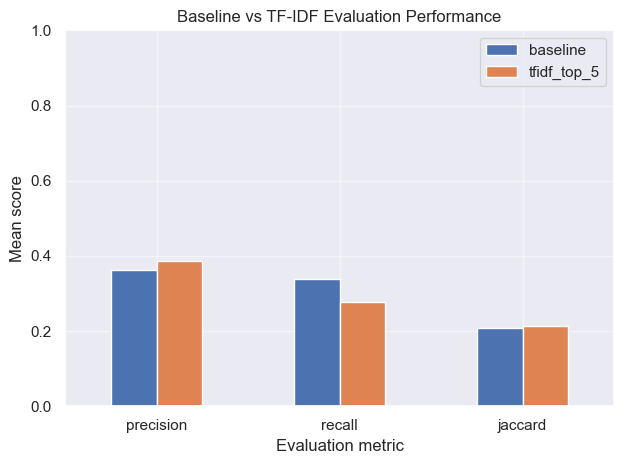

In [38]:
# Compare baseline and TF-IDF evaluation performance
model_comparison.plot(kind = 'bar')
plt.title('Baseline vs TF-IDF Evaluation Performance')
plt.ylabel('Mean score')
plt.xlabel('Evaluation metric')
plt.ylim(0, 1)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig('../figures/baseline_vs_tfidf_performance.png')
plt.show()

## 4. Statistical analysis

Inspect assumptions (Normality, Equal Variance) before ANOVA test.

In [39]:
# Define gap results file path
gap_results_file = '../outputs/gaps/gap_results.csv'

# Define recommendation results file path
recommendation_file = '../outputs/recommendations/course_recommendations.csv'

In [40]:
# Read resume-job gap results
gap_results = pd.read_csv(gap_results_file)

# Read course recommendation results
recommendations = pd.read_csv(recommendation_file)

### 4.1. Resume-job gap by job category

In [41]:
# Convert similarity into a simple gap score
gap_results['gap_score'] = 1 - gap_results['cosine_similarity']

In [42]:
# Calculate mean gap score for each job
job_gap_scores = gap_results.groupby(['job_id', 'category'], as_index = False)['gap_score'].mean()

# Check job counts by category
print(job_gap_scores['category'].value_counts())

category
Data and Analytics         45
Computer and IT            20
Software Engineering       19
Science and Engineering     9
Name: count, dtype: int64


In [43]:
# Summarize job-level gap scores by category
category_summary = job_gap_scores.groupby('category')['gap_score'].agg(['count','mean', 'median', 'std'])

print(category_summary.round(4))

                         count    mean  median     std
category                                              
Computer and IT             20  0.9739  0.9757  0.0058
Data and Analytics          45  0.9768  0.9767  0.0039
Science and Engineering      9  0.9718  0.9689  0.0098
Software Engineering        19  0.9733  0.9745  0.0067


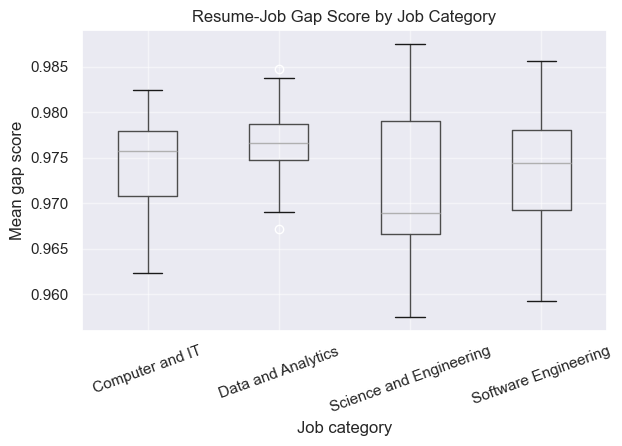

In [44]:
# Plot gap-score distribution by category
job_gap_scores.boxplot(column = 'gap_score', by = 'category')
plt.title('Resume-Job Gap Score by Job Category')
plt.suptitle('')
plt.xlabel('Job category')
plt.ylabel('Mean gap score')
plt.xticks(rotation = 20)
plt.tight_layout()
plt.savefig('../figures/resume-job_gap_score_per_category.png')
plt.show()

In [45]:
# Create gap-score groups by category
computer_it = job_gap_scores[job_gap_scores['category'] == 'Computer and IT' ]['gap_score']

data_analytics = job_gap_scores[job_gap_scores['category'] == 'Data and Analytics' ]['gap_score']

software_engineering = job_gap_scores[job_gap_scores['category'] == 'Software Engineering']['gap_score']

science_engineering = job_gap_scores[job_gap_scores['category'] == 'Science and Engineering']['gap_score']

#### Check Normality

In [46]:
# Check normality for each category
print('Computer and IT:', stats.normaltest(computer_it).pvalue)
print('Data and Analytics:', stats.normaltest(data_analytics).pvalue)
print('Software Engineering:', stats.normaltest(software_engineering).pvalue)
print('Science and Engineering:', stats.normaltest(science_engineering).pvalue)

Computer and IT: 0.366011178081637
Data and Analytics: 0.7943846736619089
Software Engineering: 0.5746309044010423
Science and Engineering: 0.7952928283532295


#### Check Equal Variance

In [47]:
# Check whether category variances are similar
levene_pvalue = stats.levene(computer_it, data_analytics, software_engineering,science_engineering).pvalue

print(levene_pvalue)

0.0027249027186135


#### AVOVA One-way Test

In [48]:
# Compare category means using Welch's ANOVA
anova_pvalue = stats.f_oneway(computer_it, data_analytics, software_engineering,science_engineering).pvalue

print(anova_pvalue)

0.025656691126085315


### 4.2. Course Recommendation

In [49]:
# Keep only the highest-ranked course for each resume-job pair
top_recommendations = recommendations[recommendations['rank'] == 1].copy()

In [50]:
# Calculate mean top recommendation score for each job
job_recommendation_scores = top_recommendations.groupby(['job_id', 'job_category'],as_index = False)['course_similarity'].mean()

In [51]:
# Summarize recommendation scores by job category
recommendation_summary = job_recommendation_scores.groupby('job_category')['course_similarity'].agg(['count', 'mean', 'median', 'std'])

print(recommendation_summary.round(4))

                         count    mean  median     std
job_category                                          
Computer and IT             20  0.0194  0.0163  0.0080
Data and Analytics          45  0.0270  0.0251  0.0106
Science and Engineering      9  0.0253  0.0218  0.0104
Software Engineering        19  0.0245  0.0223  0.0101


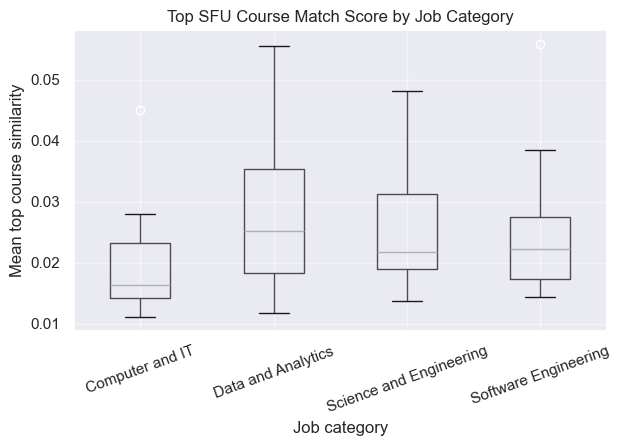

In [52]:
# Plot top course recommendation scores by category
job_recommendation_scores.boxplot(column = 'course_similarity', by = 'job_category')
plt.title('Top SFU Course Match Score by Job Category')
plt.suptitle('')
plt.xlabel('Job category')
plt.ylabel('Mean top course similarity')
plt.xticks(rotation = 20)
plt.tight_layout()
plt.savefig('../figures/course_match_score_per_category.png')
plt.show()

In [53]:
# Count the most frequently ranked first courses
top_course_counts = top_recommendations[['course_num', 'course_name']].value_counts().head(10)

print(top_course_counts)

course_num  course_name                                                   
CMPT 732    Big Data Lab I                                                    1427
CMPT 410    Machine Learning                                                   929
CMPT 733    Big Data Lab II                                                    904
CMPT 372    Web II - Server-side Development                                   616
CMPT 473    Software Testing, Reliability and Security                         469
CMPT 788    Information Privacy                                                399
CMPT 782    Cybersecurity Lab I                                                322
CMPT 727    Mathematical and Probabilistic Foundations of Machine Learning     252
CMPT 475    Requirements Engineering                                           231
CMPT 729    Reinforcement Learning                                             231
Name: count, dtype: int64


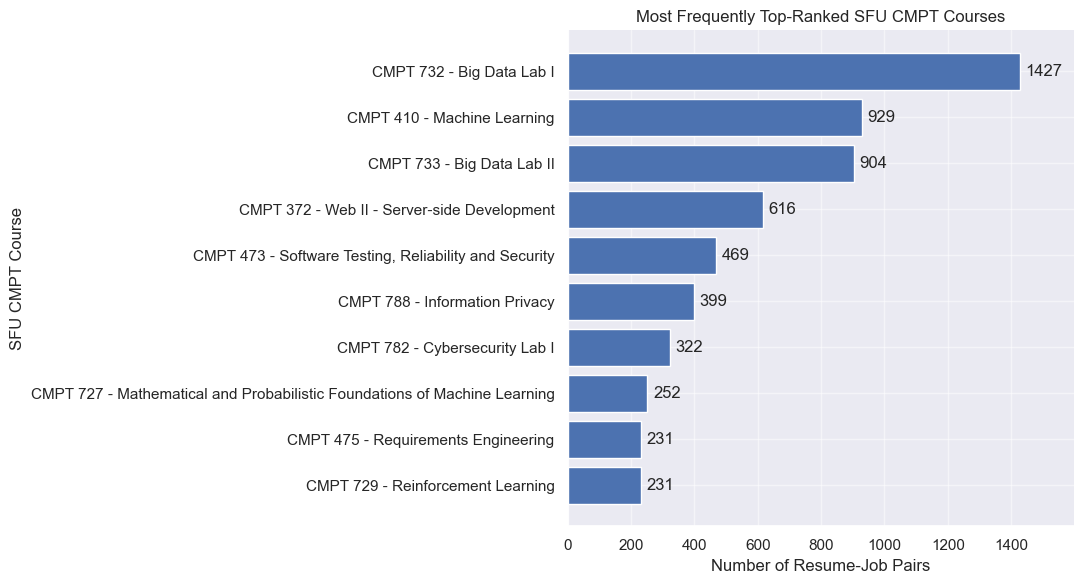

In [54]:
# Convert course counts to dataframe
top_course_plot = top_course_counts.reset_index(name = 'count')

# Create shorter course labels
top_course_plot['course_label'] = top_course_plot['course_num'] + ' - ' + top_course_plot['course_name']

# Sort courses so the largest bar appears at the top
top_course_plot = top_course_plot.sort_values(by = 'count', ascending = True)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize = (11, 6))

ax.barh(top_course_plot['course_label'], top_course_plot['count'])

# Add count labels to each bar
ax.bar_label(ax.containers[0], padding = 4, fmt = '%d')

# Add chart titles and labels
ax.set_title('Most Frequently Top-Ranked SFU CMPT Courses')
ax.set_xlabel('Number of Resume-Job Pairs')
ax.set_ylabel('SFU CMPT Course')

# Add space for value labels
ax.set_xlim(0, top_course_plot['count'].max() * 1.12)

# Remove unnecessary chart borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve spacing
plt.tight_layout()
plt.savefig('../figures/most_freq_match_courses.png')
plt.show()

In [55]:
# Create recommendation-score groups
computer_it_course = job_recommendation_scores[job_recommendation_scores['job_category'] == 'Computer and IT']['course_similarity']

data_analytics_course = job_recommendation_scores[job_recommendation_scores['job_category'] == 'Data and Analytics']['course_similarity']

science_engineering_course = job_recommendation_scores[job_recommendation_scores['job_category'] == 'Science and Engineering']['course_similarity']

software_engineering_course = job_recommendation_scores[job_recommendation_scores['job_category'] == 'Software Engineering']['course_similarity']

#### Check Normality

In [56]:
# Check normality of recommendation scores
print('Computer and IT:', stats.normaltest(computer_it_course).pvalue)
print('Data and Analytics:', stats.normaltest(data_analytics_course).pvalue)
print('Science and Engineering:', stats.normaltest(science_engineering_course).pvalue)
print('Software Engineering:', stats.normaltest(software_engineering_course).pvalue)

Computer and IT: 0.00017561426357558818
Data and Analytics: 0.13471907168546202
Science and Engineering: 0.04228787149469035
Software Engineering: 0.0002107016521977824


#### Check Equal Variance

In [57]:
# Check equal variance assumption
recommendation_levene = stats.levene(computer_it_course, data_analytics_course,science_engineering_course, software_engineering_course)

print('Levene p-value:', recommendation_levene.pvalue)

Levene p-value: 0.4128633030509742


#### ANOVA One-Way Test

In [58]:
# Compare recommendation scores using one-way ANOVA
recommendation_anova_pvalue = stats.f_oneway(computer_it_course, data_analytics_course,science_engineering_course, software_engineering_course).pvalue

print('ANOVA p-value:',recommendation_anova_pvalue)

ANOVA p-value: 0.05188049937545576


### 4.3 Baseline vs TF-IDF Comparison

In [59]:
# Calculate paired Jaccard differences
evaluation_results['jaccard_difference'] = evaluation_results['tfidf_jaccard_5'] - evaluation_results['baseline_jaccard']

# Summarize paired model differences
print(evaluation_results['jaccard_difference'].describe())

count    20.000000
mean      0.005545
std       0.076157
min      -0.100000
25%       0.000000
50%       0.000000
75%       0.004464
max       0.222222
Name: jaccard_difference, dtype: float64


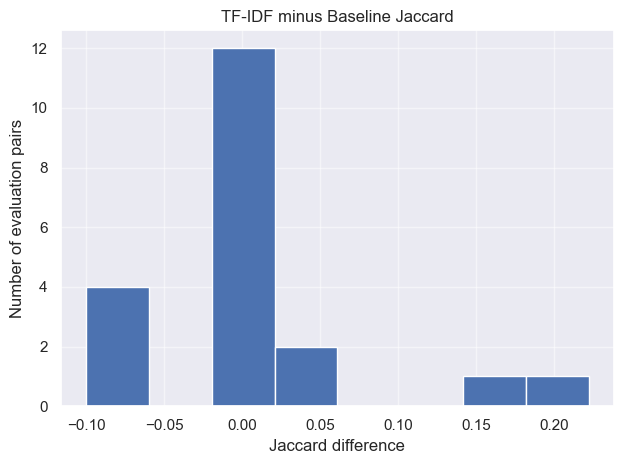

In [60]:
# Plot paired Jaccard differences
evaluation_results['jaccard_difference'].hist(bins = 8)
plt.title('TF-IDF minus Baseline Jaccard')
plt.xlabel('Jaccard difference')
plt.ylabel('Number of evaluation pairs')
plt.tight_layout()
plt.savefig('../figures/baseline_vs_tfidf_jaccard_diff.png')
plt.show()

In [61]:
# Check normality of paired differences
difference_normality_pvalue = stats.normaltest(evaluation_results['jaccard_difference']).pvalue

print(difference_normality_pvalue)

0.0030216653416662606


In [62]:
# Compare mean Jaccard performance
print('Baseline mean Jaccard:', round(evaluation_results['baseline_jaccard'].mean(), 4))
print('TF-IDF mean Jaccard@5:', round(evaluation_results['tfidf_jaccard_5'].mean(), 4))
print('Mean difference:', round(evaluation_results['jaccard_difference'].mean(), 4))

Baseline mean Jaccard: 0.2086
TF-IDF mean Jaccard@5: 0.2142
Mean difference: 0.0055


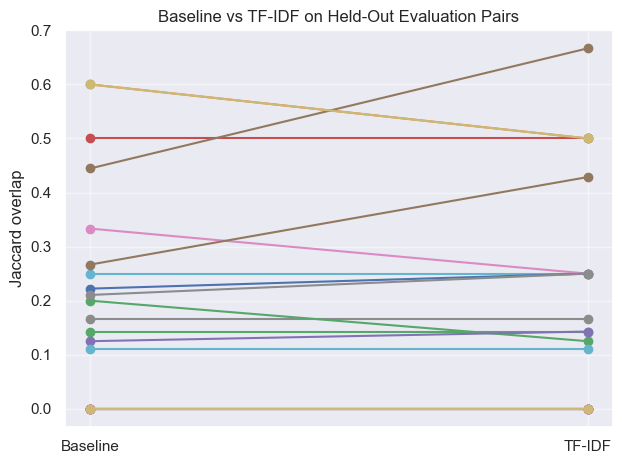

In [63]:
# Plot paired baseline and TF-IDF Jaccard scores
plt.plot([0, 1], evaluation_results[['baseline_jaccard', 'tfidf_jaccard_5']].T, marker = 'o')
plt.xticks([0, 1], ['Baseline', 'TF-IDF'])
plt.ylabel('Jaccard overlap')
plt.title('Baseline vs TF-IDF on Held-Out Evaluation Pairs')
plt.tight_layout()
plt.savefig('../figures/baseline_vs_tfidf_jaccard_overlap.png')
plt.show()

## 5. Findings and limitations

State what the data supports and what it does not support.

### Main findings
- The most frequently requested technical skills were Python, SQL, Agile, Azure, and machine learning. Python appeared in 44 of 93 job postings, followed by SQL in 32, Agile in 31, Azure in 29, and machine learning in 27. AWS, GCP, cybersecurity, and Java were also common.
- Skill requirements differed noticeably across job categories. Data and Analytics showed particularly high demand for Python (62.2%), SQL (51.1%), and machine learning (40.0%). Software Engineering emphasized Python and Java (both 52.6%), Agile (52.6%), and CI/CD (42.1%). Computer and IT showed stronger emphasis on Azure, AWS, and cybersecurity, each appearing in 40.0% of postings in that category.
- The keyword baseline achieved mean precision of 0.3637, recall of 0.3375, and Jaccard overlap of 0.2086 on the 20 held-out evaluation pairs.
- The TF-IDF model achieved Precision@5 of 0.3858, Recall@5 of 0.2775, and Jaccard@5 of 0.2142. Compared with the baseline, TF-IDF produced slightly higher precision and Jaccard overlap, but lower recall.
- The paired model results showed only a very small average improvement in Jaccard overlap for TF-IDF. Mean Jaccard increased from 0.2086 for the baseline to 0.2142 for TF-IDF, an average difference of only 0.0055. Most evaluation pairs showed little or no change, although a small number improved more substantially.
- Job-category gap scores showed some differences descriptively, but statistical significance should not yet be claimed. Data and Analytics had the highest mean gap score (0.9768), while Science and Engineering had the lowest (0.9718). However, Levene's test indicated unequal variances (p = 0.0027), so the standard one-way ANOVA currently run in the notebook is not the appropriate final test.
- The highest-ranked SFU courses tended to focus on big data, machine learning, server-side development, and software quality/security. CMPT 732 (Big Data Lab I) was the most frequently top-ranked course with 1,427 resume–job pairs, followed by CMPT 410 (Machine Learning) with 929 and CMPT 733 (Big Data Lab II) with 904. CMPT 372 (Web II – Server-side Development) and CMPT 473 (Software Testing, Reliability and Security) were also frequently recommended.

### Limitations
- Public resumes do not represent SFU students.
- Job postings do not represent the entire technology labour market.
- Technical-skill extraction depends on the curated dictionary.
- A missing term does not prove a person lacks the competency.
- TF-IDF measures textual emphasis, not practical proficiency.
- Course descriptions are shorter than full learning outcomes.
- Course similarity does not prove mastery.
- Human labels are subjective.
- The held-out evaluation sample is small.